In [12]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt



from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.layers import Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.utils import to_categorical

In [13]:
(x_train,y_train),(x_test,y_test)=tf.keras.datasets.cifar10.load_data()

x_train=x_train.astype("float32")/255.0
x_test=x_test.astype("float32")/255.0

y_train=to_categorical(y_train,10)
y_test=to_categorical(y_test,10)

print(x_train.shape)
print(x_test.shape)

(50000, 32, 32, 3)
(10000, 32, 32, 3)


In [14]:
IMG_SIZE = 96

x_train = tf.image.resize(
    x_train,
    (IMG_SIZE, IMG_SIZE)
)

x_test = tf.image.resize(
    x_test,
    (IMG_SIZE, IMG_SIZE)
)

x_train = x_train.numpy()
x_test = x_test.numpy()

print(x_train.shape)
print(x_test.shape)

(50000, 96, 96, 3)
(10000, 96, 96, 3)


In [16]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(96,96,3)
)

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)

outputs = Dense(
    10,
    activation='softmax'
)(x)

model = Model(
    inputs=base_model.input,
    outputs=outputs
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 96, 96, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 48, 48,    │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 48, 48,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 48, 48,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 48, 48,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 48, 48,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 48, 48,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 48, 48,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 48, 48,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 49, 49,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 24, 24,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 24, 24,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 24, 24,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 24, 24,    │      2,304 │ block_1_depthwis

 Total params: 2,270,794 (8.66 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [17]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [18]:
history1 = model.fit(
    x_train,
    y_train,
    epochs=5,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)

print("Evaluating Before Fine-Tuning...")

loss_before, acc_before = model.evaluate(
    x_test,
    y_test,
    verbose=0
)

print(f"Test Accuracy Before Fine-Tuning: {acc_before:.4f}")
print(f"Test Loss Before Fine-Tuning: {loss_before:.4f}")


Epoch 1/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 30s 61ms/step - accuracy: 0.6522 - loss: 1.0366 - val_accuracy: 0.7710 - val_loss: 0.6671
Epoch 2/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 9s 26ms/step - accuracy: 0.7484 - loss: 0.7317 - val_accuracy: 0.7886 - val_loss: 0.6213
Epoch 3/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 9s 26ms/step - accuracy: 0.7672 - loss: 0.6823 - val_accuracy: 0.7982 - val_loss: 0.5924
Epoch 4/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - accuracy: 0.7759 - loss: 0.6580 - val_accuracy: 0.7970 - val_loss: 0.5906
Epoch 5/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - accuracy: 0.7783 - loss: 0.6449 - val_accuracy: 0.7960 - val_loss: 0.5838
Evaluating Before Fine-Tuning...
Test Accuracy Before Fine-Tuning: 0.7984
Test Loss Before Fine-Tuning: 0.5917


In [19]:
base_model.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history2 = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)
print("Evaluating After Fine-Tuning...")

loss_after, acc_after = model.evaluate(
    x_test,
    y_test,
    verbose=0
)

print("Test Accuracy After Fine-Tuning: {acc_after:.4f}")
print("Test Loss After Fine-Tuning: {loss_after:.4f}")

Epoch 1/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 100s 159ms/step - accuracy: 0.7352 - loss: 0.9244 - val_accuracy: 0.7848 - val_loss: 0.6501
Epoch 2/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 29s 82ms/step - accuracy: 0.8329 - loss: 0.5465 - val_accuracy: 0.8134 - val_loss: 0.5597
Epoch 3/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 29s 82ms/step - accuracy: 0.8656 - loss: 0.4287 - val_accuracy: 0.8260 - val_loss: 0.5179
Epoch 4/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 28s 80ms/step - accuracy: 0.8863 - loss: 0.3517 - val_accuracy: 0.8484 - val_loss: 0.4478
Epoch 5/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 29s 81ms/step - accuracy: 0.9020 - loss: 0.2938 - val_accuracy: 0.8704 - val_loss: 0.3924
Epoch 6/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 29s 81ms/step - accuracy: 0.9160 - loss: 0.2467 - val_accuracy: 0.8854 - val_loss: 0.3647
Epoch 7/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 29s 81ms/step - accuracy: 0.9273 - loss: 0.2100 - val_accuracy: 0.8924 - val_loss: 0.3510
Epoch 8/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 29s 81ms/step - accuracy: 0.9364 - loss: 0.1825 

In [20]:
improvement = (acc_after - acc_before) * 100

print(f"Accuracy Improvement: {improvement:.2f}%")

Accuracy Improvement: 10.73%


In [21]:
from sklearn.metrics import (
    classification_report,
    precision_score,
    recall_score,
    f1_score
)

y_pred = model.predict(x_test)

y_pred_labels = y_pred.argmax(axis=1)
y_true_labels = y_test.argmax(axis=1)

precision = precision_score(
    y_true_labels,
    y_pred_labels,
    average='macro'
)

recall = recall_score(
    y_true_labels,
    y_pred_labels,
    average='macro'
)

f1 = f1_score(
    y_true_labels,
    y_pred_labels,
    average='macro'
)

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step
Precision: 0.9065656302696883
Recall: 0.9056999999999998
F1 Score: 0.9058814070437226


In [22]:
class_names = [
    'airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck'
]

print(
    classification_report(
        y_true_labels,
        y_pred_labels,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

    airplane       0.93      0.88      0.90      1000
  automobile       0.96      0.93      0.95      1000
        bird       0.89      0.91      0.90      1000
         cat       0.80      0.83      0.82      1000
        deer       0.89      0.89      0.89      1000
         dog       0.88      0.86      0.87      1000
        frog       0.91      0.95      0.93      1000
       horse       0.94      0.91      0.93      1000
        ship       0.94      0.94      0.94      1000
       truck       0.93      0.95      0.94      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



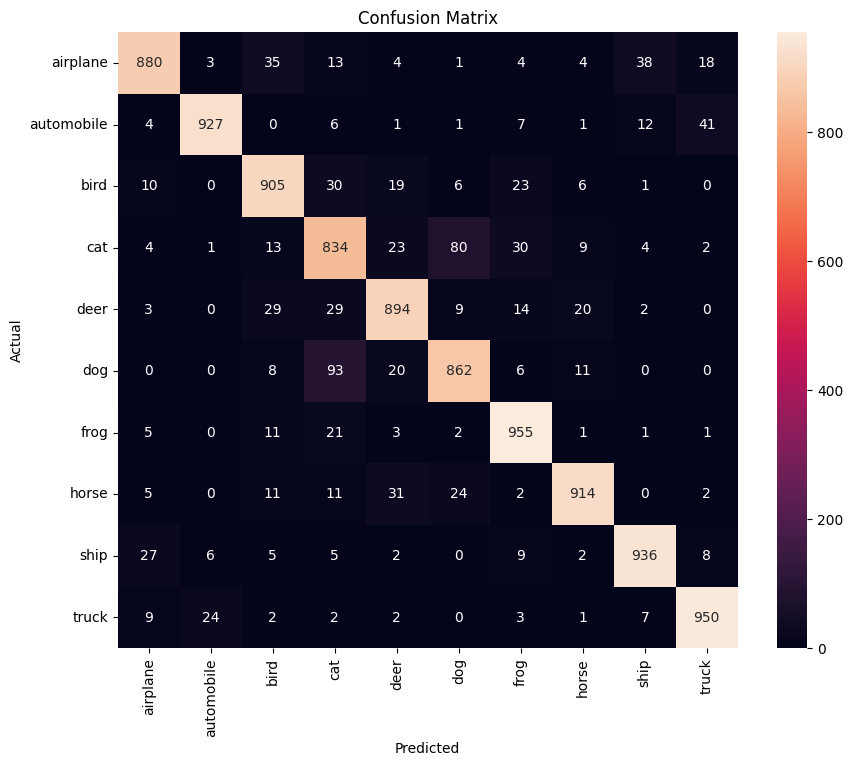

In [23]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_true_labels,
    y_pred_labels
)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

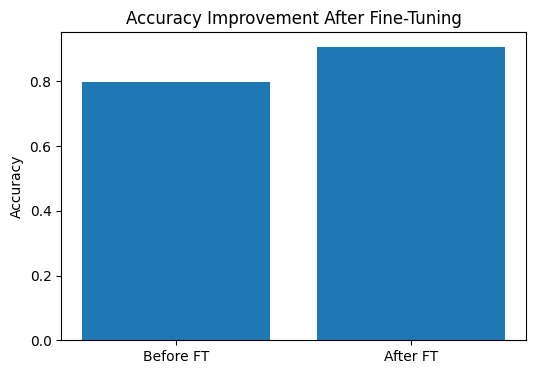

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.bar(
    ["Before FT", "After FT"],
    [acc_before, acc_after]
)

plt.ylabel("Accuracy")
plt.title("Accuracy Improvement After Fine-Tuning")

plt.show()

In [25]:
model.save("mobilenetv2_cifar10.h5")

import os

size=os.path.getsize(
    "mobilenetv2_cifar10.h5"
)/(1024*1024)

print("Model Size:",size,"MB")

Model Size: 26.3880615234375 MB
